# **MFCC-Chroma Fusion using a Dual-Channel CNN-LSTM for Lung Sound Disease Classification**


## I. Loading the dataset

---



In [20]:
# Import Statement
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import librosa as lb  # For audio loading, processing, and padding.
import soundfile as sf  # For saving processed audio files.
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# Modify data_dir as per your naming concention
data_dir = "./Respiratory_Sound_Database"
audio_dir = os.path.join(data_dir, "audio_and_txt_files/")
diagnosis_path = os.path.join(data_dir, "patient_diagnosis.csv")  # Contains patient diagnoses

# List audio and annotation files
wav_files = sorted([f for f in os.listdir(audio_dir) if f.endswith(".wav")])  # Holds all audio files
txt_files = sorted([f for f in os.listdir(audio_dir) if f.endswith(".txt")]) # Holds all annotation files
files = sorted([s.split('.')[0] for s in os.listdir(audio_dir) if '.txt' in s]) # Holds all files files

print(f"Found {len(wav_files)} audio files and {len(txt_files)} annotation files.")

Found 920 audio files and 920 annotation files.


In [22]:
patient_data=pd.read_csv(diagnosis_path, names=['pid', 'disease'])
patient_data.head()

,pid,disease
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [23]:
# Another thing to note with these files, is the actual file name. Because they also hold information.
def get_filename_info(file):
  return file.split('_')

In [24]:
def read_icbhi_metadata(data_dir):

    audio_dir = os.path.join(data_dir, "audio_and_txt_files") # Where all of the audio files are stored in the ICBHI dataset
    diagnosis_path = os.path.join(data_dir, "patient_diagnosis.csv") # The CSV file that maps the PID to a disease within the dataset

    # Read patient diagnoses
    patient_df = pd.read_csv(diagnosis_path, names=["pid", "disease"])
    patient_df.pid = patient_df.pid.astype(int) # DF that holds PID and associated Disease

    # Read all annotation txt files
    txt_files = sorted([f for f in os.listdir(audio_dir) if f.endswith(".txt")]) # All of the annotiation files associated with the recordings

    rows = []

    # Iterate through all of the audio file annotations and create a datafram that stores all of the data. 
    # It gets the start, end, crackles, and wheezes annotations from the .txt files 
    #   and the PID from the filename itself and the actual filename too.
    for txt in txt_files:
        file = txt.replace(".txt", "")
        metadata = pd.read_csv(
            os.path.join(audio_dir, txt),
            sep="\t",
            names=["start", "end", "crackles", "wheezes"]
        )
        pid = int(get_filename_info(file)[0]) #  Gets only the first part of the filename which is the PID

        metadata["filename"] = file
        metadata["pid"] = pid

        rows.append(metadata)

    # Combine all annotations
    df = pd.concat(rows)

    # We carry out a merge of the two dataframes using the patient ID so we can have one giant dataframe with all of the necessary information
    df = df.merge(patient_df, on="pid")


    print("The total number of patients within the dataset is exactly", patient_df['pid'].count())
    print("The total number of segments of data within the entire dataset amounts to", df['pid'].count())
    print("After carrying out the join, the total number of segments of data within the entire dataset amounts to", df['pid'].count())


    # We drop disease classes with fewer than 3 unique patients
    counts = df.groupby('disease')['pid'].nunique()
    rare_classes = counts[counts < 3].index.tolist()
    if rare_classes:
        print(f"\nDropping the following rare disease classes with < 3 patients: {rare_classes}")
        df_dropped = df[~df['disease'].isin(rare_classes)].copy()
    else: 
        df_dropped = df['disease']

    
    print("\nThese rare classes have the following number of patients:")
    print(counts[rare_classes])

    print("\nThe Total number of segments that are found among these rare classes amounts to:", df[df['disease'].isin(rare_classes)]['pid'].count())

    print("\nThen, the revised total number of segments after dropping the segments of these rare classes amounts to", df_dropped['pid'].count())

    # We reset the index because of the entries we dropped. We don't want the jumps evident in the dataset because they become confusing later on
    df_dropped = df_dropped.reset_index(drop=True)
    return df_dropped


data = read_icbhi_metadata('./Respiratory_Sound_Database')
os.makedirs("outputs", exist_ok=True)
data.to_csv("outputs/df_with_rare_classes_dropped.csv")

The total number of patients within the dataset is exactly 126
The total number of segments of data within the entire dataset amounts to 6898
After carrying out the join, the total number of segments of data within the entire dataset amounts to 6898

Dropping the following rare disease classes with < 3 patients: ['Asthma', 'LRTI']

These rare classes have the following number of patients:
disease
Asthma    1
LRTI      2
Name: pid, dtype: int64

The Total number of segments that are found among these rare classes amounts to: 38

Then, the revised total number of segments after dropping the segments of these rare classes amounts to 6860


## II. Data Preprocessing


---



### Remove Outlying Respiratory Cycles

First, let us iterrate to every text file in the dataframe to observe the distribution of crackles and wheezes through a histogram.

In [25]:
# Ensure crackles and wheezes are integers
data['crackles'] = data['crackles'].astype(int)
data['wheezes'] = data['wheezes'].astype(int)

# # Loop through each unique filename
# for filename in data['filename'].unique():
#     file_data = data[data['filename'] == filename]  # Filter data for the current filename

#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Create side-by-side histograms

#     # Crackles histogram
#     axes[0].hist(file_data['crackles'], bins=[-0.5, 0.5, 1.5], edgecolor='black')
#     axes[0].set_xticks([0, 1])  # Ensure only 0 and 1 appear
#     axes[0].set_title(f'Crackles Distribution for {filename}')
#     axes[0].set_ylabel('Frequency')

#     # wheezes histogram
#     axes[1].hist(file_data['wheezes'], bins=[-0.5, 0.5, 1.5], edgecolor='black')
#     axes[1].set_xticks([0, 1])  # Ensure only 0 and 1 appear
#     axes[1].set_title(f'wheezes Distribution for {filename}')
#     axes[1].set_ylabel('Frequency')

#     # Show the histograms
#     plt.tight_layout()
#     plt.show()


After seeing the initial distribution of values, we will use Interquartile Range to detect and remove the outliers.



In [26]:
# Function to remove an outlier
def remove_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)

  IQR = Q3-Q1

  # Define the bounds for non-outlier values
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Remove rows with outliers outside of this range
  return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [27]:
cleaned_data = pd.DataFrame()

for filename in data['filename'].unique():
    file_data = data[data['filename'] == filename]

    # Remove outliers for crackles and wheezes
    file_data_cleaned = remove_outliers(file_data, 'crackles')
    file_data_cleaned = remove_outliers(file_data_cleaned, 'wheezes')

    cleaned_data = pd.concat([cleaned_data, file_data_cleaned])

In [28]:
cleaned_data.head()

,start,end,crackles,wheezes,filename,pid,disease
0,0.036,0.579,0,0,101_1b1_Al_sc_Meditron,101,URTI
1,0.579,2.450,0,0,101_1b1_Al_sc_Meditron,101,URTI
2,2.450,3.893,0,0,101_1b1_Al_sc_Meditron,101,URTI
3,3.893,5.793,0,0,101_1b1_Al_sc_Meditron,101,URTI
4,5.793,7.521,0,0,101_1b1_Al_sc_Meditron,101,URTI


In [29]:
cleaned_data

,start,end,crackles,wheezes,filename,pid,disease
0,0.036,0.579,0,0,101_1b1_Al_sc_Meditron,101,URTI
1,0.579,2.450,0,0,101_1b1_Al_sc_Meditron,101,URTI
2,2.450,3.893,0,0,101_1b1_Al_sc_Meditron,101,URTI
3,3.893,5.793,0,0,101_1b1_Al_sc_Meditron,101,URTI
4,5.793,7.521,0,0,101_1b1_Al_sc_Meditron,101,URTI
...,...,...,...,...,...,...,...
6855,11.721,13.693,1,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia
6856,13.693,15.536,0,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia
6857,15.536,17.493,0,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia
6858,17.493,19.436,1,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia


Now that we have removed the outliers from the dataset, let us see its distribution for each filename for confirmation.

In [30]:
# Ensure crackles and wheezes are integers
cleaned_data['crackles'] = data['crackles'].astype(int)
cleaned_data['wheezes'] = data['wheezes'].astype(int)

# for filename in cleaned_data['filename'].unique():
#     file_data = cleaned_data[data['filename'] == filename]

#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     # Crackles histogram
#     axes[0].hist(file_data['crackles'], bins=[-0.5, 0.5, 1.5], edgecolor='black')
#     axes[0].set_xticks([0, 1])
#     axes[0].set_title(f'Crackles Distribution for {filename}')
#     axes[0].set_ylabel('Frequency')

#     # wheezes histogram
#     axes[1].hist(file_data['wheezes'], bins=[-0.5, 0.5, 1.5], edgecolor='black')
#     axes[1].set_xticks([0, 1])
#     axes[1].set_title(f'wheezes Distribution for {filename}')
#     axes[1].set_ylabel('Frequency')

#     plt.tight_layout()
#     plt.show()




In [31]:
# Export Unbalanced dataset
cleaned_data.to_csv("unbalanced.csv")

Henceforth, we will be using the exported dataset so it is imperative you have it saved.

In [32]:
data = pd.read_csv("unbalanced.csv")


In [33]:
data

,Unnamed: 0,start,end,crackles,wheezes,filename,pid,disease
0,0,0.036,0.579,0,0,101_1b1_Al_sc_Meditron,101,URTI
1,1,0.579,2.450,0,0,101_1b1_Al_sc_Meditron,101,URTI
2,2,2.450,3.893,0,0,101_1b1_Al_sc_Meditron,101,URTI
3,3,3.893,5.793,0,0,101_1b1_Al_sc_Meditron,101,URTI
4,4,5.793,7.521,0,0,101_1b1_Al_sc_Meditron,101,URTI
...,...,...,...,...,...,...,...,...
6414,6855,11.721,13.693,1,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia
6415,6856,13.693,15.536,0,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia
6416,6857,15.536,17.493,0,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia
6417,6858,17.493,19.436,1,0,226_1b1_Pl_sc_LittC2SE,226,Pneumonia


In [34]:
# Method to convert to a specific sampling rate.

# The raw data is the audio file and sr denotes the sampling rate which is 22050 hz by default
def getAudioSegmenet(raw_data, start, end, sr=22050):
  max_ind = len(raw_data) # Get the total number of samples in raw_data

  # Basically, get the relevant audio segment while ensuring it is within bounds
  start_ind = min(int(start * sr), max_ind)
  end_ind = min(int(end * sr), max_ind)
  return raw_data[start_ind: end_ind]

In [36]:
# Only for making the unbalanced dataset
os.makedirs('unbalanced_audio_files')

import librosa as lb  # For audio loading, processing, and padding.
import soundfile as sf  # For saving processed audio files.

# Initialize counters for file indexing and total processed files.
i, c = 0, 0

# Iterate over each row in the `data` DataFrame.
for index, row in data.iterrows():
    start = row['start']  # Start time of the segment.
    end = row['end']  # End time of the segment.
    filename = row['filename']  # filename for the audio file.


    # Construct the full path to the original audio file.
    audio_file_loc = audio_dir + filename + '.wav'

    # Adjust the filename if the same patient has multiple cycles.
    if index > 0:
        # Check if the current file is the same as the previous file in the DataFrame.
        if data.iloc[index - 1]['filename'] == filename:
            i += 1  # Increment the counter to differentiate the file.
        else:
            i = 0  # Reset the counter for a new file.
    filename = filename + '_' + str(i) + '.wav'  # Append the counter to the filename.

    # Define the save path for the processed audio file.
    save_path = 'unbalanced_audio_files/' + filename
    c += 1  # Increment the count of processed files.

    # Load the audio file using Librosa.
    audioArr, sampleRate = lb.load(audio_file_loc)

    # Extract the desired audio segment using the `getPureSample` function.
    pureSample = getAudioSegmenet(audioArr, start, end, sampleRate)


    # Save the padded audio segment to the specified path.
    sf.write(file=save_path, data=pureSample, samplerate=sampleRate)

# Print the total number of files processed.
print('Total Files Processed: ', c)

/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Files Processed:  6419


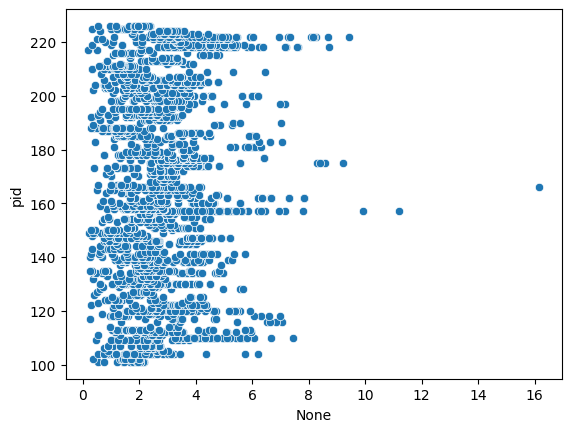

In [37]:
sns.scatterplot(x=(data.end-data.start), y=data.pid);

<Axes: ylabel='None'>

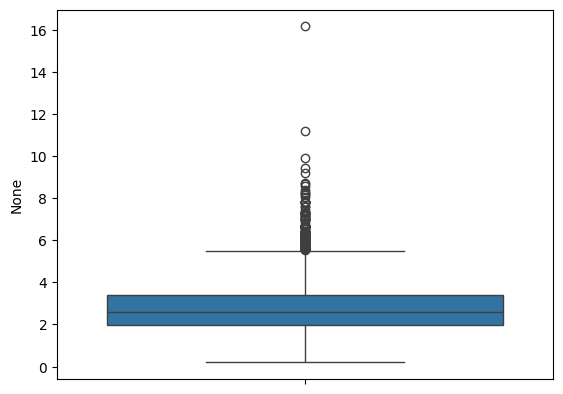

In [38]:
sns.boxplot(y=(data.end-data.start))

6 is the median value and will be the length we shall set for all our audio files

Now, we create the different audio file segements which have 6 sec ond lengths. If the duration exceeds 6 we truncate it. If the duration is shorter than 6 we add padding.

In [40]:
os.makedirs('processed_audio_files')

import librosa as lb  # For audio loading, processing, and padding.
import soundfile as sf  # For saving processed audio files.

# Initialize counters for file indexing and total processed files.
i, c = 0, 0

# Iterate over each row in the `data` DataFrame.
for index, row in data.iterrows():
    maxLen = 6  # Maximum allowed length of an audio segment (in seconds).
    start = row['start']  # Start time of the segment.
    end = row['end']  # End time of the segment.
    filename = row['filename']  # filename for the audio file.

    # If the duration of the segment exceeds the maximum length, truncate it.
    if end - start > maxLen:
        end = start + maxLen

    # Construct the full path to the original audio file.
    audio_file_loc = audio_dir + filename + '.wav'

    # Adjust the filename if the same patient has multiple cycles.
    if index > 0:
        # Check if the current file is the same as the previous file in the DataFrame.
        if data.iloc[index - 1]['filename'] == filename:
            i += 1  # Increment the counter to differentiate the file.
        else:
            i = 0  # Reset the counter for a new file.
    filename = filename + '_' + str(i) + '.wav'  # Append the counter to the filename.

    # Define the save path for the processed audio file.
    save_path = 'processed_audio_files/' + filename
    c += 1  # Increment the count of processed files.

    # Load the audio file using Librosa.
    audioArr, sampleRate = lb.load(audio_file_loc)

    # Extract the desired audio segment using the `getPureSample` function.
    pureSample = getAudioSegmenet(audioArr, start, end, sampleRate)

    # If the extracted segment is shorter than `maxLen`, pad it to the required length.
    reqLen = 6 * sampleRate  # Required length in samples for a 6-second segment.
    padded_data = lb.util.pad_center(pureSample, size=reqLen)   #ِAdd padding if the audio is less than required length

    # Save the padded audio segment to the specified path.
    sf.write(file=save_path, data=padded_data, samplerate=sampleRate)

# Print the total number of files processed.
print('Total Files Processed: ', c)

Total Files Processed:  6419


---------------

---



**Handling Class Imbalance**

In [41]:
import os
def extractId(filename):
    return filename.split('_')[0]

In [42]:
# Only for unbalanced dataset
path='./unbalanced_audio_files'
length=len(os.listdir(path))
index=range(length)
i=0
files_df=pd.DataFrame(index=index,columns=['pid','filename'])
for f in os.listdir(path):
    files_df.iloc[i]['pid']=extractId(f)
    files_df.iloc[i]['filename']=f
    i+=1
files_df.head()

/tmp/ipykernel_11773/4049154602.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  files_df.iloc[i]['pid']=extractId(f)
/tmp/ipykernel_11773/4049154602.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You ar

,pid,filename
0,113,113_1b1_Lr_sc_Litt3200_6.wav
1,107,107_2b5_Pr_mc_AKGC417L_5.wav
2,226,226_1b1_Ll_sc_Meditron_6.wav
3,151,151_2p3_Ll_mc_AKGC417L_5.wav
4,166,166_1p1_Pr_sc_Meditron_20.wav


In [43]:
path='./processed_audio_files'
length=len(os.listdir(path))
index=range(length)
i=0
files_df=pd.DataFrame(index=index,columns=['pid','filename'])
for f in os.listdir(path):
    files_df.iloc[i]['pid']=extractId(f)
    files_df.iloc[i]['filename']=f
    i+=1
files_df.head()

/tmp/ipykernel_11773/1560990428.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  files_df.iloc[i]['pid']=extractId(f)
/tmp/ipykernel_11773/1560990428.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You ar

,pid,filename
0,113,113_1b1_Lr_sc_Litt3200_6.wav
1,107,107_2b5_Pr_mc_AKGC417L_5.wav
2,226,226_1b1_Ll_sc_Meditron_6.wav
3,151,151_2p3_Ll_mc_AKGC417L_5.wav
4,166,166_1p1_Pr_sc_Meditron_20.wav


In [44]:
files_df.pid=files_df.pid.astype('int64') # both pid's must be of same dtype for them to merge


In [45]:
data=pd.merge(files_df,patient_data,on='pid')
data.head()

,pid,filename,disease
0,113,113_1b1_Lr_sc_Litt3200_6.wav,COPD
1,107,107_2b5_Pr_mc_AKGC417L_5.wav,COPD
2,226,226_1b1_Ll_sc_Meditron_6.wav,Pneumonia
3,151,151_2p3_Ll_mc_AKGC417L_5.wav,COPD
4,166,166_1p1_Pr_sc_Meditron_20.wav,COPD


In [46]:
data.to_csv('unbalanced1.csv')

Text(0.5, 1.0, 'Classes Vs No. of Audios')

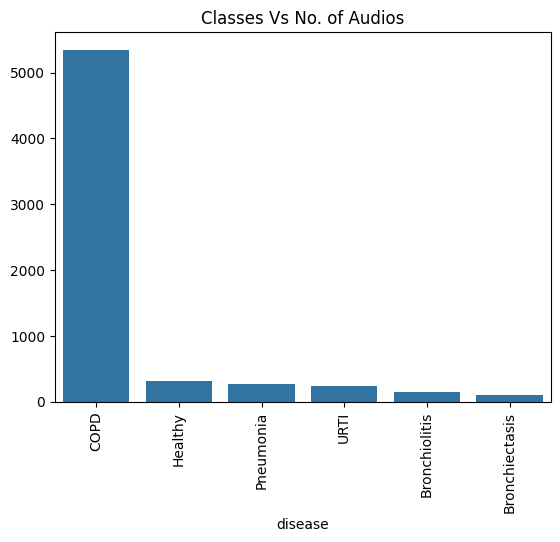

In [47]:
sns.barplot(x = data["disease"].value_counts().index,y=data["disease"].value_counts().values)
plt.xticks(rotation=90)
plt.title("Classes Vs No. of Audios")

In [48]:
disease_counts = data["disease"].value_counts()
print(disease_counts)

disease
COPD              5347
Healthy            319
Pneumonia          275
URTI               233
Bronchiolitis      147
Bronchiectasis      98
Name: count, dtype: int64


In [49]:
def augment_audio(waveform, sr, no_waveforms):
    rng = np.random.default_rng()

    # Convert to mono if stereo
    if len(waveform.shape) > 1:
        waveform = lb.to_mono(waveform)

    if no_waveforms == 5:
      # Apply augmentations
      waveforms = [
          waveform,  # Original
          lb.effects.pitch_shift(waveform, sr=sr, n_steps=(rng.uniform(0.1, 1.5))),  # Higher pitch
          lb.effects.time_stretch(waveform, rate=(rng.uniform(0.5, 0.9))),  # Slower
          lb.effects.time_stretch(waveform, rate=(rng.uniform(1.1, 1.5))),  # Faster
          waveform + 0.005 * rng.normal(size=len(waveform))  # Gaussian noise
      ]
    else:
      # Apply augmentations
      waveforms = [
          waveform,  # Original
          lb.effects.pitch_shift(waveform, sr=sr, n_steps=(rng.uniform(0.1, 3))),  # Higher pitch
          lb.effects.time_stretch(waveform, rate=(rng.uniform(0.5, 0.9))),  # Slower
          waveform + 0.005 * rng.normal(size=len(waveform))  # Gaussian noise
      ]

    # Normalize waveforms to avoid clipping
    waveforms = [lb.util.normalize(w) for w in waveforms]

    return waveforms

In [50]:
def augment_if_needed(path, sr, label, num_augmentations=3, no_waveforms=5):
    file, _ = lb.load("./processed_audio_files/" + path, sr=sr)

    if label != "COPD":  # Only augment non-COPD samples

      if label == "Healthy":
        no_waveforms=4
        num_augmentations=4
      elif label == "Pneumonia":
        num_augmentations=4
      elif label == "URTI":
        num_augmentations=6
        no_waveforms=4
      elif label == "Bronchiolitis":
        num_augmentations=9
        no_waveforms=4
      elif label == "Bronchiectasis":
        num_augmentations=11
      elif label == "LRTI":
        num_augmentations = 33
      elif label == "Asthma":
        num_augmentations= 167

      augmented_samples = []
      for _ in range(num_augmentations):
        augmented_samples.extend(augment_audio(file, sr, no_waveforms))
      return augmented_samples  # Return more augmented variations

    return [file]  # Return original if COPD

In [52]:
from scipy.io.wavfile import write
augmented_df = pd.DataFrame(columns=['pid', 'filename','disease'])
os.mkdir("./augmented")

for index, row in data.iterrows():
  augmented = augment_if_needed(row.filename, 22050, row.disease)
  i = 1
  for waveform in augmented:
    augmented_df.loc[len(augmented_df)] = {
        "pid" : row.pid,
        "filename" : row.filename + "-" + str(i),
        "disease" : row.disease
    }
    write( os.path.join("augmented/", row.filename + "-" + str(i)), 22050, waveform)
    i+=1




augmented_df

,pid,filename,disease
0,113,113_1b1_Lr_sc_Litt3200_6.wav-1,COPD
1,107,107_2b5_Pr_mc_AKGC417L_5.wav-1,COPD
2,226,226_1b1_Ll_sc_Meditron_6.wav-1,Pneumonia
3,226,226_1b1_Ll_sc_Meditron_6.wav-2,Pneumonia
4,226,226_1b1_Ll_sc_Meditron_6.wav-3,Pneumonia
...,...,...,...
32220,195,195_1b1_Ll_sc_Litt3200_0.wav-1,COPD
32221,107,107_2b4_Pr_mc_AKGC417L_0.wav-1,COPD
32222,180,180_1b4_Pl_mc_AKGC417L_3.wav-1,COPD
32223,176,176_1b4_Al_mc_AKGC417L_3.wav-1,COPD


Text(0.5, 1.0, 'Classes Vs No. of Audios')

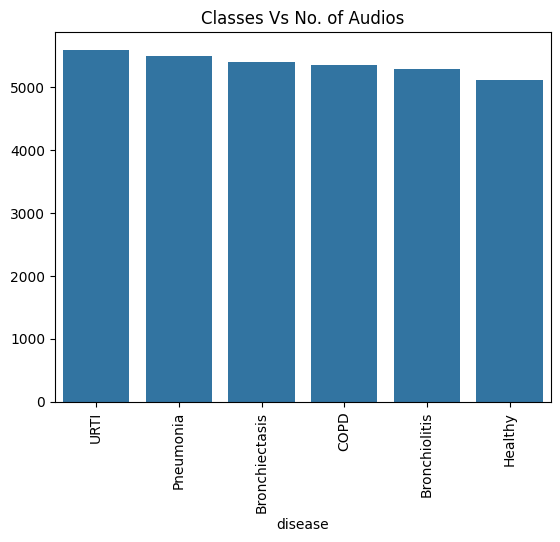

In [53]:
sns.barplot(x = augmented_df["disease"].value_counts().index,y=augmented_df["disease"].value_counts().values)
plt.xticks(rotation=90)
plt.title("Classes Vs No. of Audios")

In [54]:
print("Classifications:")
disease_counts = augmented_df["disease"].value_counts()
print(disease_counts)

Classifications:
disease
URTI              5592
Pneumonia         5500
Bronchiectasis    5390
COPD              5347
Bronchiolitis     5292
Healthy           5104
Name: count, dtype: int64


In [55]:
import shutil
SPLIT_DIR = "./outputs/final" 
UNSEEN_RATIO = 0.10
TEST_RATIO_WITHIN_DEV = 0.20

def random_split(
    pid_df,
    segments_source_dir,
    output_root_dir,
    seed=42
):
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # 1️⃣ Shuffle entire dataframe randomly (row-level)
    # --------------------------------------------------
    shuffled_df = pid_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    total = len(shuffled_df)

    unseen_size = int(round(total * UNSEEN_RATIO))

    val_df = shuffled_df.iloc[:unseen_size]
    dev_df = shuffled_df.iloc[unseen_size:]

    test_size = int(round(len(dev_df) * TEST_RATIO_WITHIN_DEV))

    test_df = dev_df.iloc[:test_size]
    train_df = dev_df.iloc[test_size:]

    # --------------------------------------------------
    # 2️⃣ Save CSV outputs
    # --------------------------------------------------
    split_csv_dir = "outputs/final"
    os.makedirs(split_csv_dir, exist_ok=True)

    train_df.to_csv(f"{split_csv_dir}/train_segments.csv", index=False)
    test_df.to_csv(f"{split_csv_dir}/test_segments.csv", index=False)
    val_df.to_csv(f"{split_csv_dir}/val_segments.csv", index=False)

    # --------------------------------------------------
    # 3️⃣ Prepare segment directories
    # --------------------------------------------------
    train_dir = os.path.join(output_root_dir, "train_segments")
    test_dir  = os.path.join(output_root_dir, "test_segments")
    val_dir   = os.path.join(output_root_dir, "val_segments")

    # Remove old folders
    shutil.rmtree(train_dir, ignore_errors=True)
    shutil.rmtree(test_dir, ignore_errors=True)
    shutil.rmtree(val_dir, ignore_errors=True)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    # --------------------------------------------------
    # 4️⃣ Function to copy files
    # --------------------------------------------------
    def copy_files(df, destination_dir):
        count = 0
        for file in df["filename"]:
            src_path = os.path.join(segments_source_dir, file)


            dest_path = os.path.join(destination_dir, os.path.basename(file))
            if not os.path.exists(src_path):
                print("Missing path:", src_path)
                count+=1
                continue

            shutil.copy(src_path, dest_path)
        print("TOTAL MISSING: ", count)
        

    # Copy segments
    copy_files(train_df, train_dir)
    copy_files(test_df, test_dir)
    copy_files(val_df, val_dir)

    print("\nSplit complete.")
    print(f"Train: {len(train_df)} segments")
    print(f"Test:  {len(test_df)} segments")
    print(f"Val:   {len(val_df)} segments")

    return train_df, test_df, val_df

train_strat, test_strat, val_strat = random_split(
    augmented_df,
    "./augmented",
    SPLIT_DIR,
    seed=42
)


TOTAL MISSING:  0
TOTAL MISSING:  0
TOTAL MISSING:  0

Split complete.
Train: 23202 segments
Test:  5801 segments
Val:   3222 segments


In [57]:
shutil.copytree('./outputs/final/train_segments',
                "../dataset/train-segments")

shutil.copy("./outputs/final/train_segments.csv",
                "../dataset/train_segments.csv")



shutil.copytree('./outputs/final/test_segments',
                "../dataset/test-segments")

shutil.copy("./outputs/final/test_segments.csv",
                "../dataset/test_segments.csv")


shutil.copytree('./outputs/final/val_segments',
                "../dataset/val-segments")

shutil.copy("./outputs/final/val_segments.csv",
                "../dataset/val_segments.csv")

FileExistsError: [Errno 17] File exists: '../dataset/train-segments'